# Analisi Esplorativa dei Dati (EDA) - Progetto HeisenBank
In questo notebook effettuiamo un'indagine approfondita sul dataset delle frodi bancarie. L'obiettivo è comprendere la distribuzione delle variabili, identificare pattern sospetti e preparare il terreno per il modello di **Quantum Machine Learning**.

### Obiettivi della fase:
1. Caricare il dataset e verificarne l'integrità.
2. Analizzare la struttura delle feature (Clienti, Richiesta, Rischio, Dispositivo).
3. Confermare l'assenza di valori nulli (già rilevata nelle analisi preliminari).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazioni estetiche per i grafici
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Caricamento del dataset
dataset_path = 'dataset/Base.csv'
data = pd.read_csv(dataset_path)

# 2. Panoramica rapida
print(f"Dimensioni del Dataset: {data.shape[0]} righe, {data.shape[1]} colonne")
print("-" * 30)
display(data.head())

# 3. Verifica Integrità (Valori mancanti)
missing_values = data.isnull().sum().sum()
print(f"\nTotale valori mancanti: {missing_values}")
if missing_values == 0:
    print("Conferma: Il dataset è completo e non presenta 'null values'.")

### Analisi della Variabile Target: `fraud_bool`
Come rilevato, il dataset è fortemente **sbilanciato**. Questo è un comportamento tipico nei problemi di "fraud detection", dove le frodi rappresentano solo una piccola frazione del traffico totale. 

*   **Classe 0 (Legittima):** ~98.9%
*   **Classe 1 (Frode):** ~1.1%

Questa disparità richiederà tecniche di bilanciamento (come il downsampling visto nel modello QML) prima dell'addestramento.

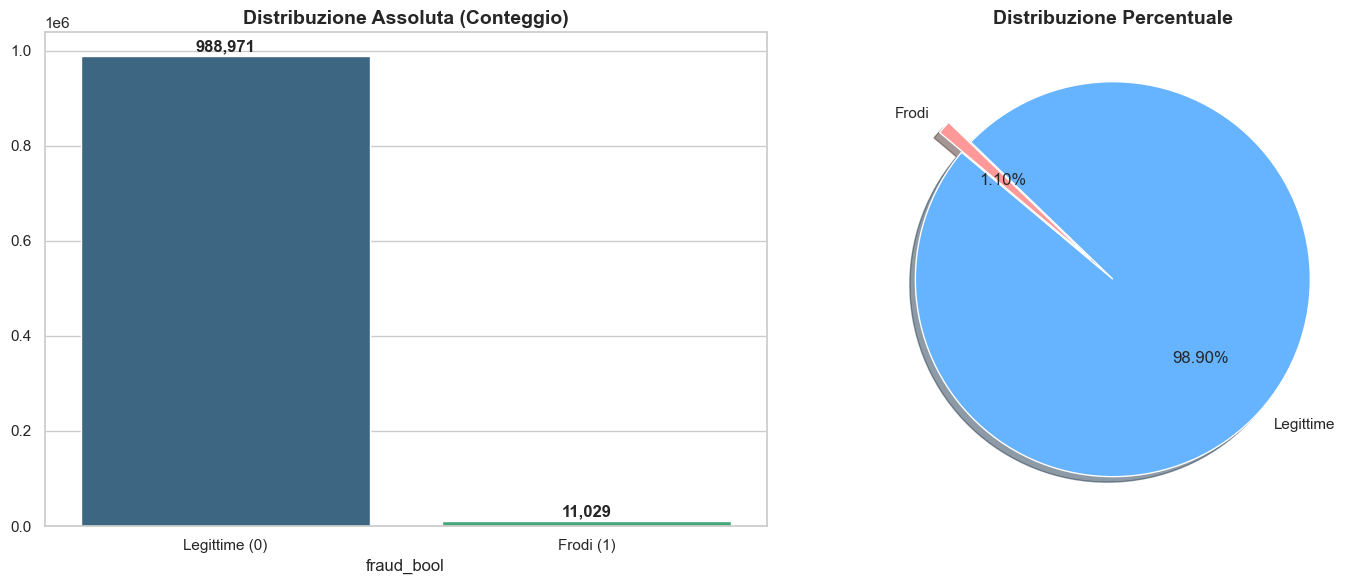

In [4]:
# Calcolo distribuzione
target_counts = data['fraud_bool'].value_counts()

# Visualizzazione Creativa
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Grafico 1: Barplot (Corretto per evitare FutureWarning e UserWarning)
sns.barplot(
    x=target_counts.index, 
    y=target_counts.values, 
    ax=ax[0], 
    hue=target_counts.index,  # Assegniamo hue per evitare il warning sulla palette
    palette="viridis", 
    legend=False              # Nascondiamo la legenda perché ridondante
)

ax[0].set_title("Distribuzione Assoluta (Conteggio)", fontsize=14, fontweight='bold')
ax[0].set_xticks([0, 1]) # Impostiamo i tick prima dei label per evitare UserWarning
ax[0].set_xticklabels(['Legittime (0)', 'Frodi (1)'])

# Aggiunta dei numeri sopra le barre
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 10000, f'{v:,}', ha='center', fontweight='bold')

# Grafico 2: Pie chart con percentuali
colors = ['#66b3ff','#ff9999']
ax[1].pie(target_counts, labels=['Legittime', 'Frodi'], autopct='%1.2f%%', 
        startangle=140, colors=colors, explode=(0, 0.15), shadow=True)
ax[1].set_title("Distribuzione Percentuale", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Analisi delle Correlazioni
Per identificare quali variabili influenzano maggiormente il comportamento del target, calcoliamo la matrice di correlazione. 
Prestiamo particolare attenzione alle variabili di **Velocity** (frequenza delle richieste) e ai punteggi di **Rischio di Credito**, che spesso mostrano pattern distintivi nelle attività fraudolente.

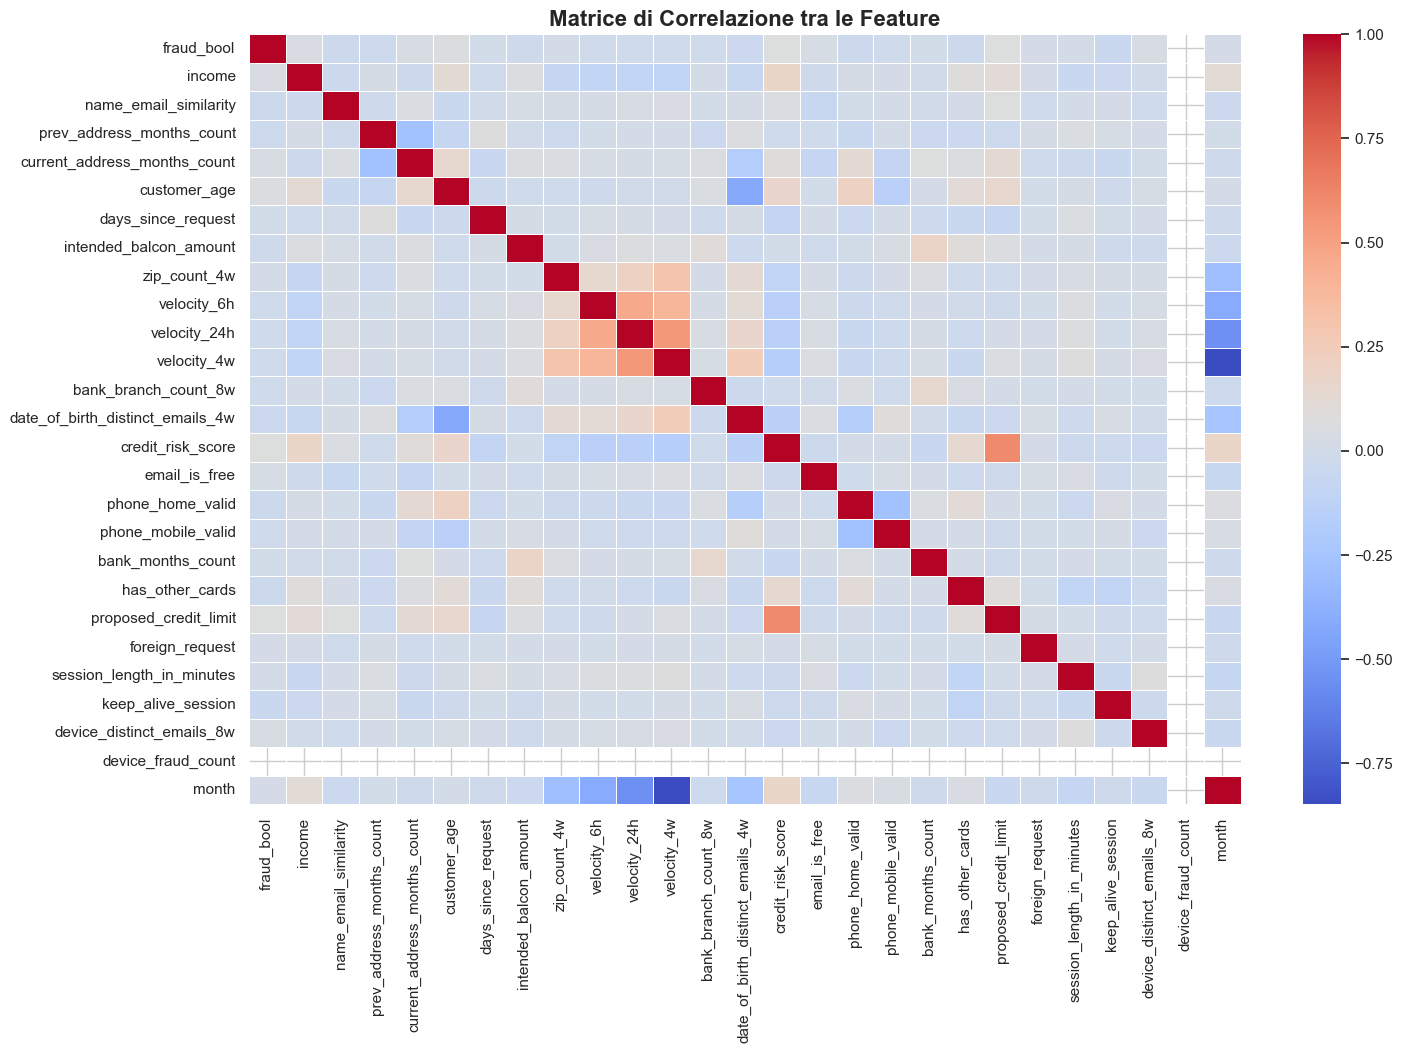

Top 5 variabili più correlate positivamente alla frode:
credit_risk_score            0.070624
proposed_credit_limit        0.068907
customer_age                 0.062959
income                       0.045079
device_distinct_emails_8w    0.035704
Name: fraud_bool, dtype: float64

Top 5 variabili più correlate negativamente alla frode:
has_other_cards                    -0.035156
name_email_similarity              -0.036720
date_of_birth_distinct_emails_4w   -0.043224
keep_alive_session                 -0.050296
device_fraud_count                       NaN
Name: fraud_bool, dtype: float64


In [3]:
# Selezioniamo solo le colonne numeriche per la correlazione
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[numeric_cols].corr()

# Visualizzazione Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice di Correlazione tra le Feature", fontsize=16, fontweight='bold')
plt.show()

# Focus sulle correlazioni con il target
fraud_corr = corr_matrix['fraud_bool'].sort_values(ascending=False)
print("Top 5 variabili più correlate positivamente alla frode:")
print(fraud_corr[1:6])
print("\nTop 5 variabili più correlate negativamente alla frode:")
print(fraud_corr.tail(5))

### Schema delle Feature Analizzate
In base alle analisi effettuate, possiamo classificare i dati nelle seguenti categorie logiche:

| Categoria | Feature Principali | Descrizione |
| :--- | :--- | :--- |
| **Profilo Cliente** | `income`, `customer_age`, `employment_status` | Dati socio-economici del richiedente. |
| **Dati Dispositivo** | `device_os`, `device_fraud_count`, `source` | Metadati tecnici per identificare hardware sospetto. |
| **Metriche Velocity** | `velocity_6h`, `zip_count_4w`, `velocity_24h` | Analisi della frequenza e del volume delle richieste. |
| **Rischio & Verifica** | `credit_risk_score`, `name_email_similarity` | Punteggi di affidabilità e controlli di identità. |
| **Transazione** | `intended_balcon_amount`, `proposed_credit_limit` | Dati finanziari legati alla specifica domanda di credito. |

# Conclusioni dell'Analisi Esplorativa

Dalle analisi effettuate emergono i seguenti punti chiave:

1.  **Sbilanciamento Estremo:** La variabile target `fraud_bool` richiede obbligatoriamente tecniche di campionamento (come il **Downsampling** già implementato) o l'uso di metriche specifiche (AUC, Precision-Recall) anziché la semplice Accuracy.
2.  **Qualità dei Dati:** Non sono stati rilevati valori nulli, il che semplifica la pipeline di preprocessing.
3.  **Feature Significative:** Le variabili demografiche (`customer_age`) e finanziarie (`income`, `proposed_credit_limit`) mostrano distribuzioni differenti tra le due classi, suggerendo un buon potenziale predittivo.
4.  **Impatto Tecnico:** Le variabili legate ai dispositivi e alla frequenza delle richieste (`velocity`) saranno cruciali per il rilevamento in tempo reale.

### Prossimi Passi:
*   **Feature Engineering:** Codifica definitiva delle variabili categoriche (Label Encoding/One-Hot).
*   **Dimensionality Reduction:** Selezione delle top feature tramite Random Forest (come fatto nel notebook QML) per adattare i dati ai limiti dei qubit disponibili.
*   **Model Training:** Integrazione dei dati bilanciati nel Variational Quantum Classifier.